Klasės

In [2]:

classes = ["Tree", "Tomato", "Pizza"]


Duomenų atsisiuntimas

In [23]:
import fiftyone as fo
import fiftyone.zoo as foz


samples_per_class = 1000

# tuscias dataset, laikoma visas dataset
dataset = fo.Dataset("balanced-dataset")

# kiekvienai klasei yra atsisiunciami duomenys
for cls in classes:
    print(f"Downloading {cls}...")

    tmp_dataset = foz.load_zoo_dataset(
        "open-images-v7",
        split="train",
        label_types=["classifications"],
        classes=[cls],
        max_samples=samples_per_class,
        dataset_name=f"open-images-{cls}",
        drop_existing_dataset=True
    )

    # sujungiamas dataset is kiekvienos klases
    dataset.merge_samples(tmp_dataset)

# shuffle
dataset = dataset.shuffle()

# is viso dataset nuotrauku skaicius
print(f"Total samples: {len(dataset)}")



 100% |██████|    4.8Gb/4.8Gb [27.2s elapsed, 0s remaining, 210.0Mb/s]      
 100% |█████████████████| 1000/1000 [1.6m elapsed, 0s remaining, 10.0 files/s]      
Dataset info written to '/Users/elvinas/fiftyone/open-images-v7/info.json'
Loading 'open-images-v7' split 'train'
 100% |███████████████| 1000/1000 [2.1s elapsed, 0s remaining, 545.9 samples/s]      
Dataset 'open-images-Tree' created
Converting existing index 'filepath' to unique on dataset 'open-images-Tree'
Converting existing index 'filepath' to unique on dataset 'balanced-dataset'
Found 6 images, downloading the remaining 994
 100% |███████████████████| 994/994 [1.1m elapsed, 0s remaining, 15.2 files/s]      
Dataset info written to '/Users/elvinas/fiftyone/open-images-v7/info.json'
Loading 'open-images-v7' split 'train'
 100% |███████████████| 1000/1000 [1.5s elapsed, 0s remaining, 684.6 samples/s]         
Dataset 'open-images-Tomato' created
Converting existing index 'filepath' to unique on dataset 'open-images-Tomato'

In [4]:
from torch.utils.data import Dataset, random_split
from PIL import Image
import math
import fiftyone as fo

# dataset'as, leidziantis naudoti daugeli zymenu
class MultiLabelDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB") # paverciama i rgb, kad butu 3 inputai pradzioj
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

# pertikrinti dataset taip, kad tikrai butu pamineti mano label'ai
def load_fiftyone_samples(dataset, classes):
    samples = []
    for sample in dataset:
        img_path = sample.filepath
        present = set()
        absent = set()

        # yra tiek pozityviu, tiek negatyviu zymenu
        if sample.positive_labels is not None:
            for cls in sample.positive_labels.classifications:
                if cls.label in classes:
                    present.add(cls.label)

        if sample.negative_labels is not None:
            for cls in sample.negative_labels.classifications:
                if cls.label in classes:
                    absent.add(cls.label)

        # kartais del klaidu, gali nebuti tinkamo label
        label = []
        for c in classes:
            if c in present:
                label.append(1.0)
            elif c in absent:
                label.append(0.0)
            else:
                label.append(0.0)

        if sum(l for l in label if not math.isnan(l)) > 0:
            samples.append((img_path, label))

    return samples

# uzloadinti subalansuota dataset
dataset = fo.load_dataset("balanced-dataset")

# ne visi automatiskai atsiusti duomenys tures tinkama label...
all_samples = load_fiftyone_samples(dataset, classes)
print(f"Total samples with at least one label: {len(all_samples)}")

/Users/elvinas/Documents/VU studijos/6 semestras/Software Testing/GMM/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples with at least one label: 1994


In [5]:
import torch
import torch.nn as nn

# naudoti mps, nes macbookas, yra specialiai skirtas device'as machine learningui
print(torch.backends.mps.is_available())
device = torch.device('mps')
print(device)

# klasifikacijos modelis
class ClassificationModel(nn.Module):
    def __init__(self):
        super(ClassificationModel, self).__init__()

        # modelio zingsniai einantys vienas po kito
        self.steps = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding='same'), # 3 inputai -> 8 outputai
            # kernel_size -> 3x3 langas
            nn.BatchNorm2d(8), # gera praktika normalizuoti, kad butu geriau mokomasi
            nn.ReLU(), # palaiko teigiamas reiksmes, neigiamos virsta i nuli. Padeda mokytis.
            nn.Conv2d(8, 8, kernel_size=3, padding='same'), # 8 -> 8
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 128x128 → 64x64 sumazina paveiksliuka


            nn.Conv2d(8, 16, kernel_size=3, padding='same'), # 8 -> 16
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 64x64 -> 32x32


            nn.Conv2d(16, 16, kernel_size=3, padding='same'), # 16 -> 16
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding='same'), # 16 -> 16
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 32x32 -> 16x16


            nn.Flatten(), # 1D vektorius
            nn.Linear(16 * 16 * 16, 64), # is 4096 inputo paverciama i 64 outputs
            nn.ReLU(),
            #nn.Dropout(0.35),       # dropout, kad butu mokomasi, nes butu overfitting
                                    # turejo blogesni efekta negu norejau
            nn.Linear(64, 3) # is 64 inputs -> 3 outputs
        )

    def forward(self, x):
        x = self.steps(x)
        return x




True
mps


In [6]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transforms_train = transforms.Compose([
    transforms.Resize((128, 128)),       # pakeičia dydį į 128×128
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip() # prideda randomness trainingo duomenims
])

transforms_test = transforms.Compose([
    transforms.Resize((128, 128)),       # pakeičia dydį į 128×128
    transforms.ToTensor(),
])

n_train = int(0.8 * len(all_samples)) # 80% datos bus train, 20% test
n_test  = len(all_samples) - n_train
train_samples, test_samples = random_split(all_samples, [n_train, n_test])

# train_dataset = datasets.ImageFolder('data/train', transform = transforms_train)
# test_dataset = datasets.ImageFolder('data/test', transform = transforms_test)

train_dataset = MultiLabelDataset(list(train_samples), transform=transforms_train)
test_dataset  = MultiLabelDataset(list(test_samples),  transform=transforms_test)

num_workers = 0 # meta errorus kai daugiau, galbut del mano custom dataset
batch_size = 20

train_loader = DataLoader(train_dataset, batch_size = batch_size, num_workers = num_workers, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, num_workers = num_workers, shuffle = False)

print(f'Train: {len(train_dataset)}, Test: {len(test_dataset)}')

Train: 1595, Test: 399


In [7]:
from datetime import datetime
import numpy as np
def train(model, loader, epoch_count = 10, lr = 1e-3):
    loss_func = torch.nn.BCEWithLogitsLoss() # BCE - nes multi-label
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # zinant kaip blogai modelis pasirode, patikrina, kaip pakeisti svoriu vertes, kad modelis klystu maziau
    # learning rate standartine yra 1e-3 (0.001), is esmes zingsnio dydis keiciant svorius

    model.train()
    start_time = datetime.now()

    for epoch in range(epoch_count):
        loss_acum = []
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device) # sumappinami images ir labels
            optimizer.zero_grad() # praeito zingsnio skaiciavimai panaikinami
            pred = model(images) # predictionai
            loss = loss_func(pred, labels) # losses paskaiciavimai
            loss.backward() # paskaiciuojama, kaip kiekvienas svoris prisidejo prie klaidu skaiciaus
            optimizer.step() # optimizuojami svoriai, kad butu sumazintos klaidos
            loss_acum.append(loss.item())
        current_time = datetime.now()
        elapsed = seconds_to_time((current_time - start_time).total_seconds())
        print(f'Epoch: {epoch}, Time: {elapsed}, Loss: {np.mean(loss_acum)}')



def seconds_to_time(seconds):
    s = int(seconds) % 60
    m = int(seconds) // 60
    if m < 1:
        return f'{s}s'
    h = m // 60
    m = m % 60
    if h < 1:
        return f'{m}m{s}s'
    return f'{h}h{m}m{s}s'

In [8]:
from sklearn.metrics import classification_report
def evaluate(model, loader, threshold=0.5):
    model.eval() # evaluation mode'as

    correct_predictions = 0
    total_predictions = 0

    all_preds = []
    all_labels = []

    start_time = datetime.now()
    for data in loader:
        images = data[0].to(device)
        labels = data[1].to(device).float()

        with torch.no_grad():
            pred = model(images)

        # sigmoid'e, nes noriu, kad keletas klasiu galetu buti teisingos
        prob = torch.sigmoid(pred)

        # tikrinu, ar probability atitinka threshold kriterijus
        label_pred = (prob >= threshold).float()

        # visi turi sutapti labeliai
        correct_predictions += (label_pred == labels).all(dim=1).sum()
        total_predictions += images.shape[0]

        all_preds.append(label_pred.cpu())
        all_labels.append(labels.cpu())

    current_time = datetime.now()
    per_image = (current_time - start_time).total_seconds() / total_predictions

    # visi predictionai ir labeliai - concatinate
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    exact_match = correct_predictions / total_predictions
    print(f'Time: {per_image * 1000:.2f}ms')
    print(f'Exact Match Accuracy:  {exact_match:.4f}')
    print()

    # library, kuri sugeneruoja reporta, kad nereiketu man paciam rasyt f1, precision, recall
    report = classification_report(
        all_labels,
        all_preds,
        target_names=classes,
        zero_division=0
    )
    print(report)


In [9]:
model = ClassificationModel().to(device)
print(f'Parameter count: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

train(model, train_loader, epoch_count = 20)
evaluate(model, test_loader)

# hammingo tikslumas


Parameter count: 269,147
Epoch: 0, Time: 11s, Loss: 0.45725986640900373
Epoch: 1, Time: 22s, Loss: 0.34395609218627216
Epoch: 2, Time: 32s, Loss: 0.3208665497601032
Epoch: 3, Time: 44s, Loss: 0.28370158076286317
Epoch: 4, Time: 54s, Loss: 0.2723161162808537
Epoch: 5, Time: 1m5s, Loss: 0.25409427415579555
Epoch: 6, Time: 1m16s, Loss: 0.23762557487934827
Epoch: 7, Time: 1m27s, Loss: 0.227153551671654
Epoch: 8, Time: 1m38s, Loss: 0.20586548354476691
Epoch: 9, Time: 1m49s, Loss: 0.1993528780527413
Epoch: 10, Time: 2m0s, Loss: 0.20012113952543586
Epoch: 11, Time: 2m10s, Loss: 0.17805242035537958
Epoch: 12, Time: 2m21s, Loss: 0.17339976434595883
Epoch: 13, Time: 2m32s, Loss: 0.14338563522323966
Epoch: 14, Time: 2m43s, Loss: 0.14411008392926306
Epoch: 15, Time: 2m53s, Loss: 0.14762611518381163
Epoch: 16, Time: 3m4s, Loss: 0.11282203020527959
Epoch: 17, Time: 3m15s, Loss: 0.11263060171622782
Epoch: 18, Time: 3m25s, Loss: 0.10037346195895225
Epoch: 19, Time: 3m36s, Loss: 0.08614406888373197
Tim

In [10]:
def print_class_balance(dataset, class_names, set_name):
    # dataset.samples yra - (image_path, label_vector)
    # label_vector yra sarasas kaip [1.0, 0.0, 1.0]

    counts = {c: 0 for c in class_names}
    total_samples = len(dataset)

    for _, label_vector in dataset.samples:
        for idx, value in enumerate(label_vector):
            if value == 1.0:
                counts[class_names[idx]] += 1

    print(f"--- {set_name} Balance ({total_samples} images) ---")
    for cls in class_names:
        count = counts[cls]
        percentage = (count / total_samples * 100) if total_samples > 0 else 0
        print(f"{cls:<10}: {count} ({percentage:.1f}%)")
    print()

# pasiziureti training ir test duomenu balansa
print_class_balance(train_dataset, classes, "Train Set")
print_class_balance(test_dataset, classes, "Test Set")

--- Train Set Balance (1595 images) ---
Tree      : 648 (40.6%)
Tomato    : 435 (27.3%)
Pizza     : 523 (32.8%)

--- Test Set Balance (399 images) ---
Tree      : 159 (39.8%)
Tomato    : 117 (29.3%)
Pizza     : 130 (32.6%)



In [11]:
evaluate(model, test_loader, 0.5)

Time: 6.96ms
Exact Match Accuracy:  0.7920

              precision    recall  f1-score   support

        Tree       0.89      0.94      0.91       159
      Tomato       0.75      0.79      0.77       117
       Pizza       0.91      0.71      0.80       130

   micro avg       0.85      0.82      0.84       406
   macro avg       0.85      0.81      0.83       406
weighted avg       0.86      0.82      0.83       406
 samples avg       0.82      0.83      0.82       406



Best threshold for Tree      : 0.5872 (F1: 0.9255)
Best threshold for Tomato    : 0.8036 (F1: 0.7925)
Best threshold for Pizza     : 0.1474 (F1: 0.8604)


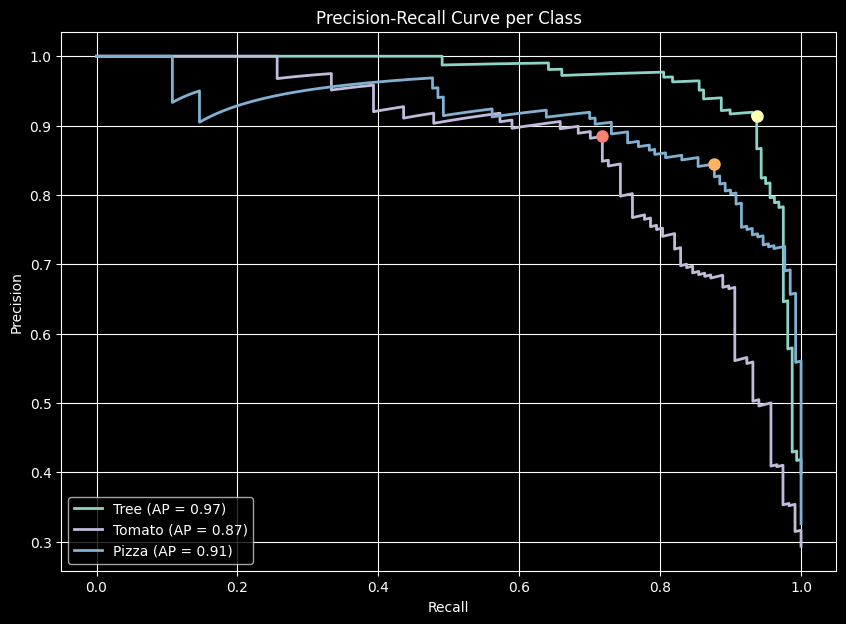

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall(model, loader, class_names):
    model.eval()

    all_probs = []
    all_labels = []

    # surinkti visas prognozes ir tiesas
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)  # sigmoide, nes daugelis zymenu

            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    # concat viska
    y_scores = torch.cat(all_probs).numpy()  # prognozes
    y_true = torch.cat(all_labels).numpy()   # tiesos


    plt.figure(figsize=(10, 7))

    # kiekvienai klasei po linija
    for i, class_name in enumerate(class_names):
        precision, recall, thresholds = precision_recall_curve(y_true[:, i], y_scores[:, i])

        f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        best_f1 = f1_scores[best_idx]

        average_precision = average_precision_score(y_true[:, i], y_scores[:, i])

        plt.plot(recall, precision, lw=2, label=f'{class_name} (AP = {average_precision:.2f})')

        plt.plot(recall[best_idx], precision[best_idx], marker='o', markersize=8)
        print(f"Best threshold for {class_name:10}: {best_threshold:.4f} (F1: {best_f1:.4f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve per Class")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_precision_recall(model, test_loader, classes)

In [11]:
torch.save(model.state_dict(), "model.pth")